In [1]:
%pip install matplotlib

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv("raw_metadata.csv")
print(df.info())

print("Dataset Shape:", df.shape)

print("First 5 rows:")
df.head()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   video_id      1000 non-null   str  
 1   title         1000 non-null   str  
 2   publish_date  1000 non-null   str  
dtypes: str(3)
memory usage: 23.6 KB
None
Dataset Shape: (1000, 3)
First 5 rows:


,video_id,title,publish_date
0,1Z-8HxlLAHk,Kids and young people: stay curious and be wil...,2026-03-30 12:17:27+00:00
1,ehkDsePv3W8,Here's a cool and easy way to work with colors...,2026-03-29 12:43:24+00:00
2,uWRdzJTpcpI,Do web devs NEED to understand low-level progr...,2026-03-28 12:32:40+00:00
3,GC5CLCgnvm0,"When things are new and a little scary, embrac...",2026-03-27 12:18:22+00:00
4,tZef2ZzbyuQ,What happens when the model CAN'T fix it? Inte...,2026-03-27 10:00:57+00:00


In [4]:
print("Column Names:", df.columns.tolist())
print("\nData Types:")
print(df.dtypes)
print("\nTotal Rows:", len(df))

Column Names: ['video_id', 'title', 'publish_date']

Data Types:
video_id        str
title           str
publish_date    str
dtype: object

Total Rows: 1000


In [5]:
print("Duplicate video_id:", df["video_id"].duplicated().sum())
print("Duplicate titles:", df["title"].duplicated().sum())
#if any duplicates are found in dataset
df = df.drop_duplicates(subset="video_id")
print("Shape after removing duplicates:", df.shape)

Duplicate video_id: 0
Duplicate titles: 1
Shape after removing duplicates: (1000, 3)


In [6]:
print("Missing values:\n")
df.isnull().sum()

Missing values:



video_id        0
title           0
publish_date    0
dtype: int64

In [7]:
df = df.dropna(subset=["video_id", "title", "publish_date"])
print("Shape after removing nulls:", df.shape)

Shape after removing nulls: (1000, 3)


In [8]:
df["publish_date"] = pd.to_datetime(df["publish_date"], errors="coerce")

df["year"] = df["publish_date"].dt.year
df["month"] = df["publish_date"].dt.month

df.head()

,video_id,title,publish_date,year,month
0,1Z-8HxlLAHk,Kids and young people: stay curious and be wil...,2026-03-30 12:17:27+00:00,2026,3
1,ehkDsePv3W8,Here's a cool and easy way to work with colors...,2026-03-29 12:43:24+00:00,2026,3
2,uWRdzJTpcpI,Do web devs NEED to understand low-level progr...,2026-03-28 12:32:40+00:00,2026,3
3,GC5CLCgnvm0,"When things are new and a little scary, embrac...",2026-03-27 12:18:22+00:00,2026,3
4,tZef2ZzbyuQ,What happens when the model CAN'T fix it? Inte...,2026-03-27 10:00:57+00:00,2026,3


In [9]:
videos_per_year = df.groupby("year").size()
videos_per_year

year
2021     59
2022    140
2023    180
2024    224
2025    264
2026    133
dtype: int64

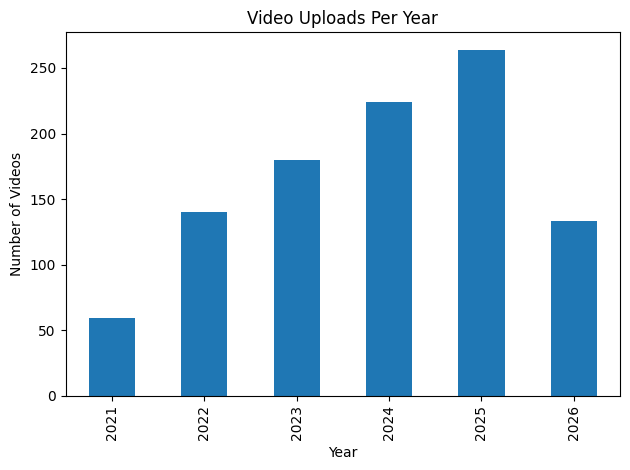

In [10]:
videos_per_year.plot(kind="bar", title="Video Uploads Per Year")
plt.xlabel("Year")
plt.ylabel("Number of Videos")
plt.tight_layout()
plt.show()

In [11]:
videos_per_month = df.groupby("month").size()
videos_per_month

month
1     111
2     106
3     112
4      60
5      64
6      56
7      57
8      77
9      77
10    100
11     98
12     82
dtype: int64

Title Analysis


In [12]:
df["title"] = df["title"].astype(str)
df["title_length"] = df["title"].str.len()

In [13]:
#for shortest title
print(df.loc[df["title_length"].idxmin(), "title"])
#for longest title
print(df.loc[df["title_length"].idxmax(), "title"])
#average title length
print(df["title_length"].mean())

Is that him?
When NOT to use AI in your hackathon project with MLH winners Cindy Cui and Alison Co [Podcast #198]
61.19


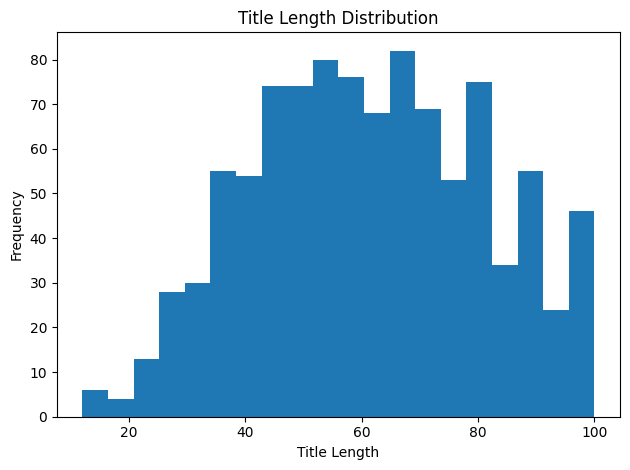

In [14]:
#Plot distribution of title lengths 
df["title_length"].plot(kind="hist", bins=20, title="Title Length Distribution")
plt.xlabel("Title Length")
plt.tight_layout()
plt.show()

In [15]:
print("Total Unique Videos:", df["video_id"].nunique())
print("Date Range:", df["publish_date"].min(), "to", df["publish_date"].max())

Total Unique Videos: 1000
Date Range: 2021-08-12 13:07:00+00:00 to 2026-03-30 12:17:27+00:00


In [16]:
df = df.head(250)
print(f"Dataset trimmed to {len(df)} rows")

Dataset trimmed to 250 rows


In [17]:
if 100 <= len(df) <= 350:
    print("Dataset size within recommended range ✅")
else:
    print("Dataset size outside recommended range ⚠")

Dataset size within recommended range ✅


In [18]:
df["title"] = df["title"].str.strip()
df["title"] = df["title"].str.replace("\n", " ", regex=False)

df.head()

,video_id,title,publish_date,year,month,title_length
0,1Z-8HxlLAHk,Kids and young people: stay curious and be wil...,2026-03-30 12:17:27+00:00,2026,3,72
1,ehkDsePv3W8,Here's a cool and easy way to work with colors...,2026-03-29 12:43:24+00:00,2026,3,72
2,uWRdzJTpcpI,Do web devs NEED to understand low-level progr...,2026-03-28 12:32:40+00:00,2026,3,88
3,GC5CLCgnvm0,"When things are new and a little scary, embrac...",2026-03-27 12:18:22+00:00,2026,3,79
4,tZef2ZzbyuQ,What happens when the model CAN'T fix it? Inte...,2026-03-27 10:00:57+00:00,2026,3,99


In [19]:
df.to_csv("cleaned_metadata.csv", index=False)
print("Cleaned dataset saved as cleaned_metadata.csv")

Cleaned dataset saved as cleaned_metadata.csv
